In [1]:
# imports 
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches 

Figure 1 D

In [2]:
# load the ground truth 
df = pd.read_csv('data/meta_hvm640.csv') # position data
xpos = df['xpos'].values.reshape(-1,1) # get x position data
ypos = df['ypos'].values.reshape(-1,1) # get y position data
xpos = np.squeeze(xpos)
ypos = np.squeeze(ypos)

In [3]:
# get the predictions from model features - to re-create these, run fig1_preds.sh
alexnet_xpreds = np.load('data/alexnet_hvm640_xpos_preds.npy')
alexnet_ypreds = np.load('data/alexnet_hvm640_ypos_preds.npy')
resnet_xpreds = np.load('data/resnet18_hvm640_xpos_preds.npy')
resnet_ypreds = np.load('data/resnet18_hvm640_ypos_preds.npy')
vgg_xpreds = np.load('data/vgg16_hvm640_xpos_preds.npy')
vgg_ypreds = np.load('data/vgg16_hvm640_ypos_preds.npy')
vit_xpreds = np.load('data/vitl32_hvm640_xpos_preds.npy')
vit_ypreds = np.load('data/vitl32_hvm640_ypos_preds.npy')
simclr_xpreds = np.load('data/simclr_resnet50_hvm640_xpos_preds.npy')
simclr_ypreds = np.load('data/simclr_resnet50_hvm640_ypos_preds.npy')
r50ssl_xpreds = np.load('data/resnet50_ssl_hvm640_xpos_preds.npy')
r50ssl_ypreds = np.load('data/resnet50_ssl_hvm640_ypos_preds.npy')
r50rob_xpreds = np.load('data/resnet50_robust_eps3_hvm640_xpos_preds.npy')
r50rob_ypreds = np.load('data/resnet50_robust_eps3_hvm640_ypos_preds.npy')

In [4]:
def gt_corrs(preds_x, preds_y, gt_x, gt_y, n_reps, interval=10):
   
    # get the correlations for each rep separately
    xcorr_raw = np.empty(n_reps)
    ycorr_raw = np.empty(n_reps)
    for p in range(n_reps):
        xcorr_temp = pearsonr(gt_x, preds_x[:,p])[0]
        ycorr_temp = pearsonr(gt_y, preds_y[:,p])[0]
        xcorr_raw[p] = xcorr_temp
        ycorr_raw[p] = ycorr_temp
    
    # check that the number of repetitions is divisible by the interval of correlation 
    if preds_x.shape[1] % interval != 0 or preds_y.shape[1] % interval != 0:
        raise ValueError(f'The number of repetitions for x_preds ({preds_x.shape[1]}) or y_preds ({preds_y.shape[1]}) is not divisible by {interval}')

    # get the average correlation across a number of reps
    checkpoint_reps = range(interval,n_reps+interval,interval)
    xcorrs = np.empty(len(checkpoint_reps))
    ycorrs = np.empty(len(checkpoint_reps))
    xstds = np.empty(len(checkpoint_reps))
    ystds = np.empty(len(checkpoint_reps))
    for i in range(len(checkpoint_reps)):
        checkpoint_rep = checkpoint_reps[i]
        xcorrs[i] = np.nanmean(xcorr_raw[:checkpoint_rep])
        ycorrs[i] = np.nanmean(ycorr_raw[:checkpoint_rep])
        xstds[i] = np.nanstd(xcorr_raw[:checkpoint_rep])
        ystds[i] = np.nanstd(ycorr_raw[:checkpoint_rep])
    
    # get the preds for the final correlation
    xfinal_preds = np.nanmean(preds_x,axis=1)
    yfinal_preds = np.nanmean(preds_y,axis=1)
    xfinal_preds_std = np.nanstd(preds_x,axis=1)
    yfinal_preds_std = np.nanstd(preds_y,axis=1)

    # compute the final correlation as the r between the mean preds and the gt
    xfinal_corr = pearsonr(gt_x,xfinal_preds)[0]
    xcl_ints = pearsonr(gt_x,xfinal_preds).confidence_interval()
    xcl = xcl_ints[1] - xcl_ints[0]

    yfinal_corr = pearsonr(gt_y,yfinal_preds)[0]
    ycl_ints = pearsonr(gt_y,yfinal_preds).confidence_interval()
    ycl = ycl_ints[1] - ycl_ints[0]
    
    # print the final correlation and cl ints for x and y 
    print(f'Final x correlation r = {xfinal_corr} +/- {xcl}')
    print(f'Final y correlation r = {yfinal_corr} +/- {ycl}')
    
    # plot the correlation across the number of reps and the final correlation for both x and y
    fig, axs = plt.subplots(nrows=2,ncols=2,sharex='row',sharey='row')
    current_size = fig.get_size_inches() 
    fig.set_size_inches(current_size[0] * 2, current_size[1] * 2.5)

    axs[0,0].errorbar(checkpoint_reps,xcorrs,yerr=xstds,fmt='o', color='darkslateblue')
    axs[0,0].set(title='Pearson r x-position predictions and ground truth across reps', xlabel='Number of Reps', ylabel='Pearson r')

    axs[0,1].errorbar(checkpoint_reps,ycorrs,yerr=ystds,fmt='o', color='lightsteelblue')
    axs[0,1].set(title='Pearson r y-position predictions and ground truth across reps', xlabel='Number of Reps')

    axs[1,0].errorbar(xfinal_preds,gt_x,xerr=xfinal_preds_std,fmt='o', color='darkslateblue')
    axs[1,0].set(title='x-position predictions vs ground truth', ylabel='ground truth', xlabel='predictions')

    axs[1,1].errorbar(yfinal_preds,gt_y,xerr=yfinal_preds_std,fmt='o', color='lightsteelblue')
    axs[1,1].set(title='y-position predictions vs ground truth', xlabel='predictions')

    for m in range(2):
        for n in range(2):
            axs[m,n].spines['top'].set_visible(False)
            axs[m,n].spines['right'].set_visible(False)
            # axs[m,n].label_outer()
            x0, x1 = axs[m,n].get_xlim()
            y0, y1 = axs[m,n].get_ylim()
            axs[m,n].set_aspect(abs(x1 - x0) / abs(y1 - y0))
    
    return [xfinal_corr, xcl, yfinal_corr, ycl]

Final x correlation r = 0.3598274935962129 +/- 0.13503778202764383
Final y correlation r = 0.49910745151931196 +/- 0.11656393900703299


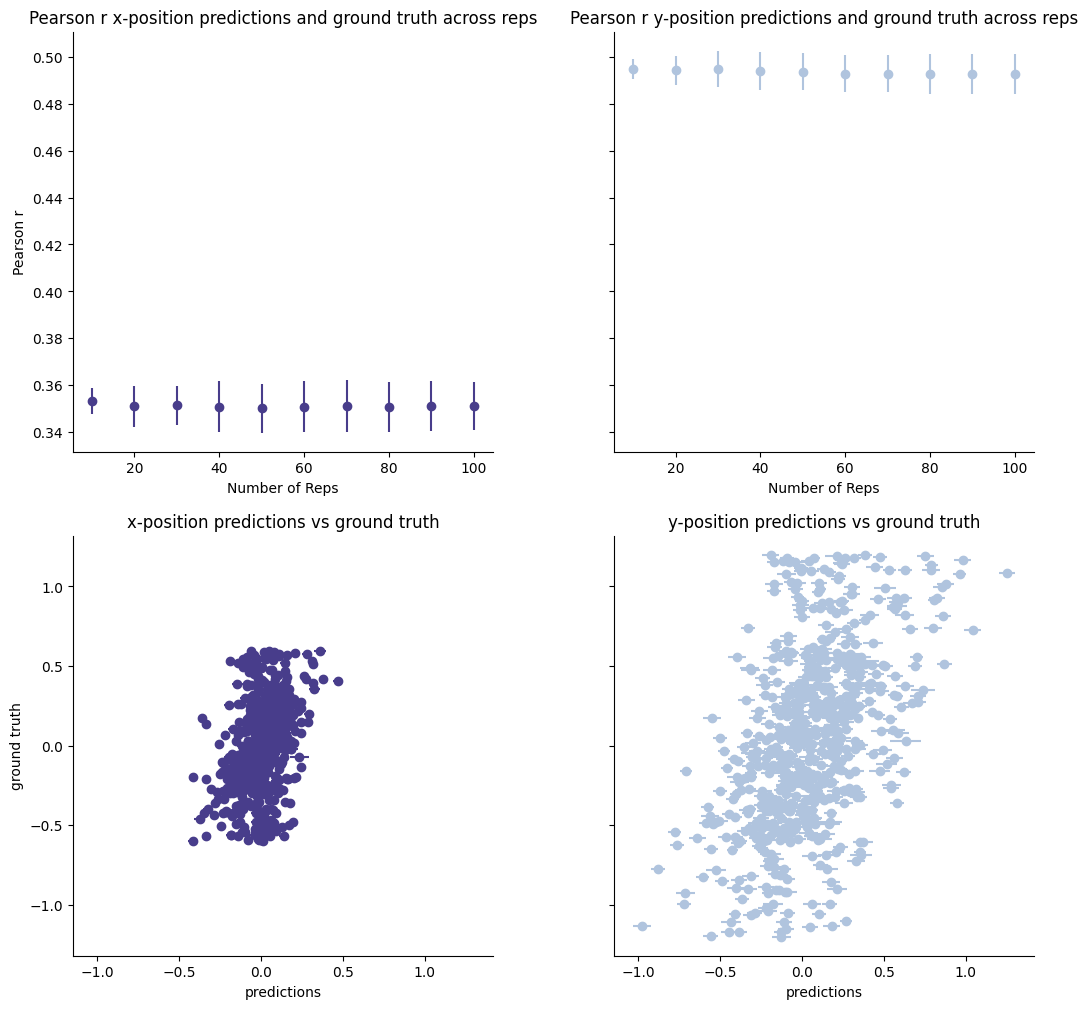

In [5]:
# alexnet
alexnet_bests = gt_corrs(alexnet_xpreds,alexnet_ypreds,xpos,ypos,100)

Final x correlation r = 0.8115300044564618 +/- 0.053130717293039975
Final y correlation r = 0.8504861928508545 +/- 0.04307196372107103


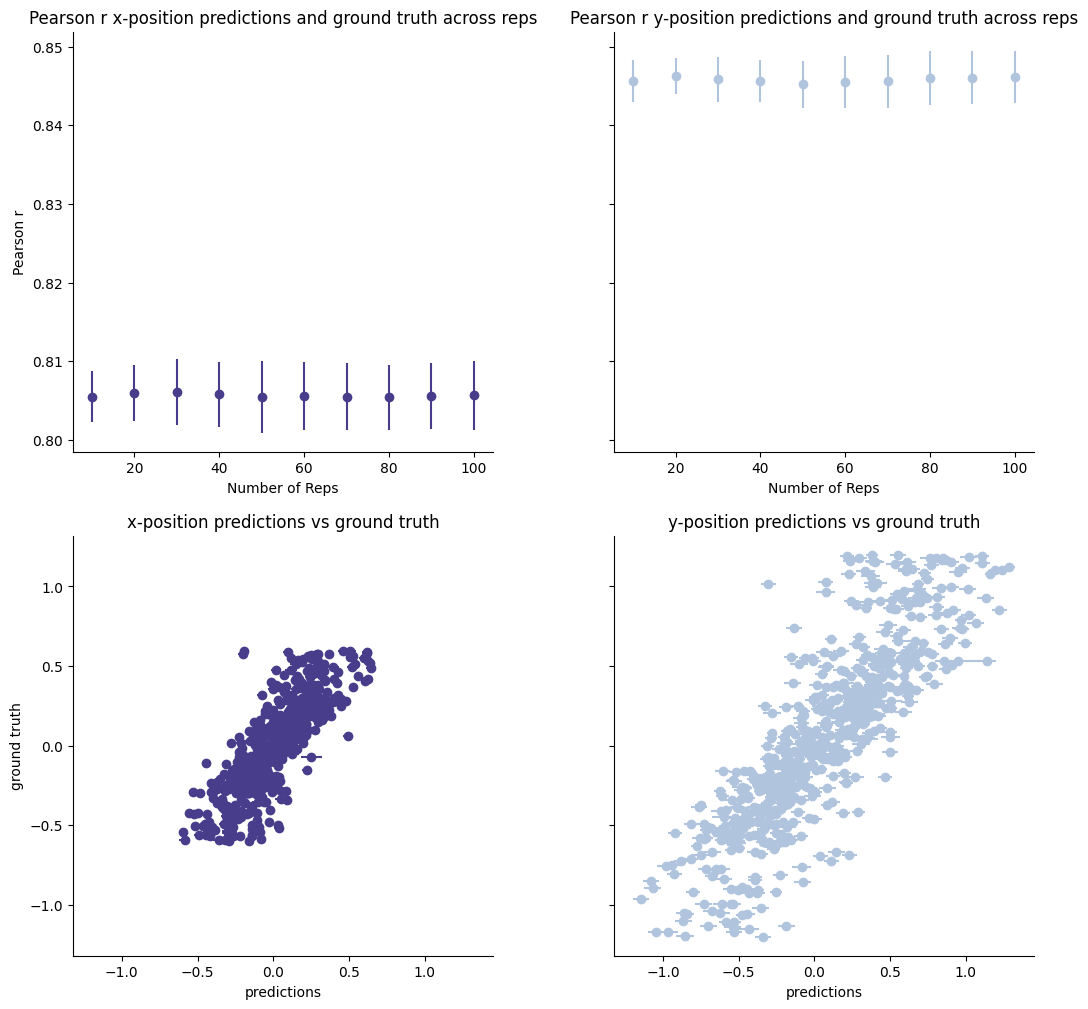

In [6]:
# resnet
resnet_bests = gt_corrs(resnet_xpreds,resnet_ypreds,xpos,ypos,100)

Final x correlation r = 0.8403838810594029 +/- 0.0457264978333366
Final y correlation r = 0.8679309005863121 +/- 0.038412103579808066


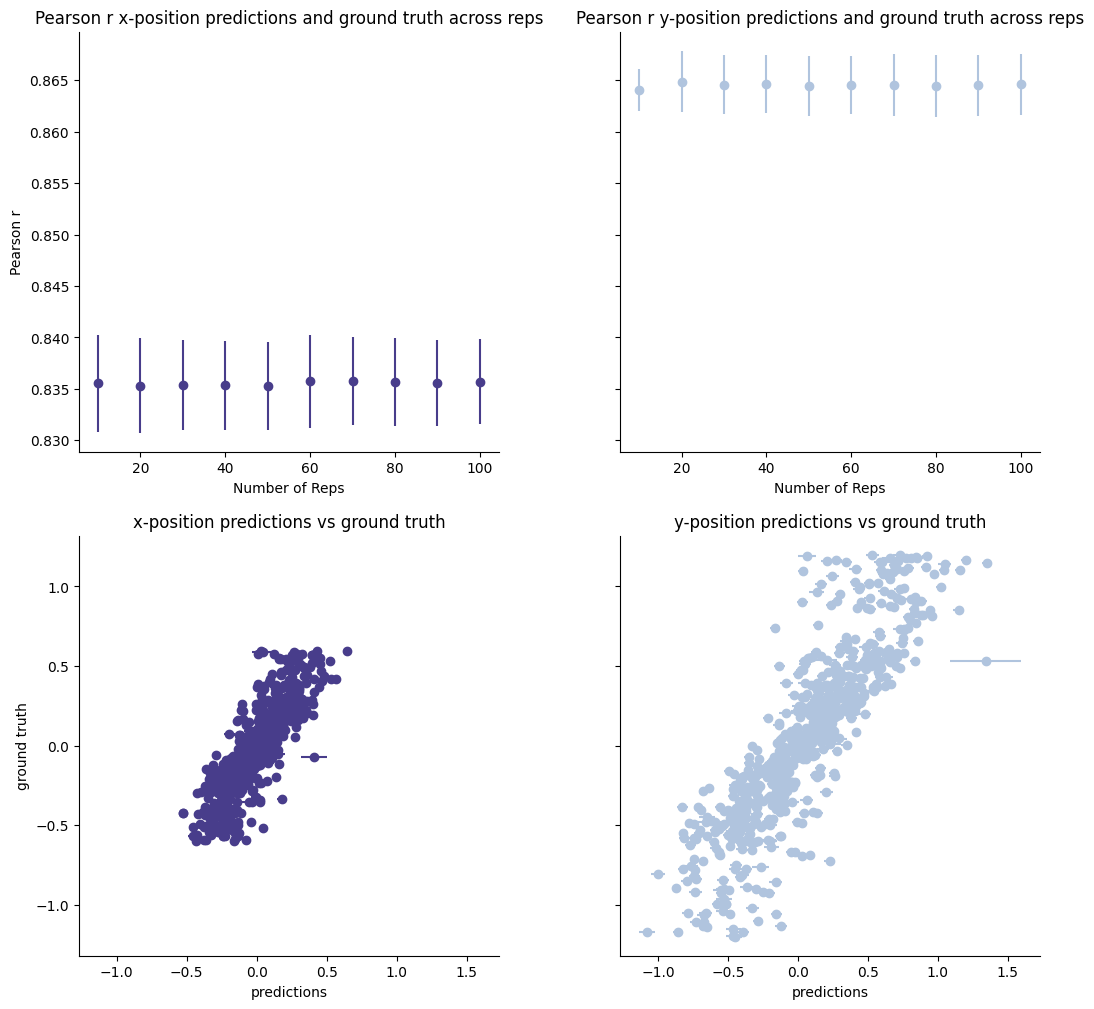

In [7]:
# vgg
vgg_bests = gt_corrs(vgg_xpreds,vgg_ypreds,xpos,ypos,100)

Final x correlation r = 0.5940910762111342 +/- 0.10050784512181954
Final y correlation r = 0.7048301572665505 +/- 0.07823255442541188


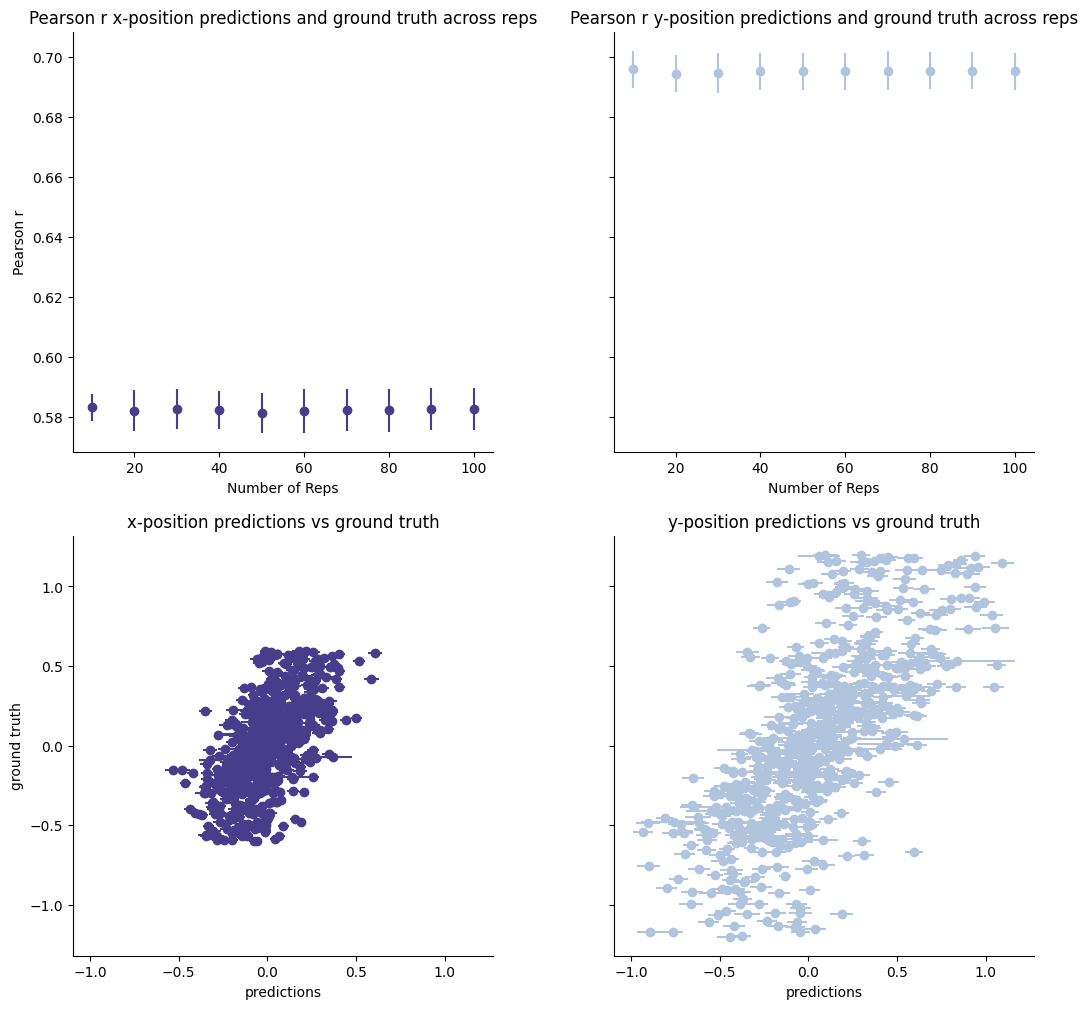

In [8]:
# vit
vit_bests = gt_corrs(vit_xpreds,vit_ypreds,xpos,ypos,100)

Final x correlation r = 0.4779587423437114 +/- 0.11975676054107126
Final y correlation r = 0.5300909898102333 +/- 0.11163521820208056


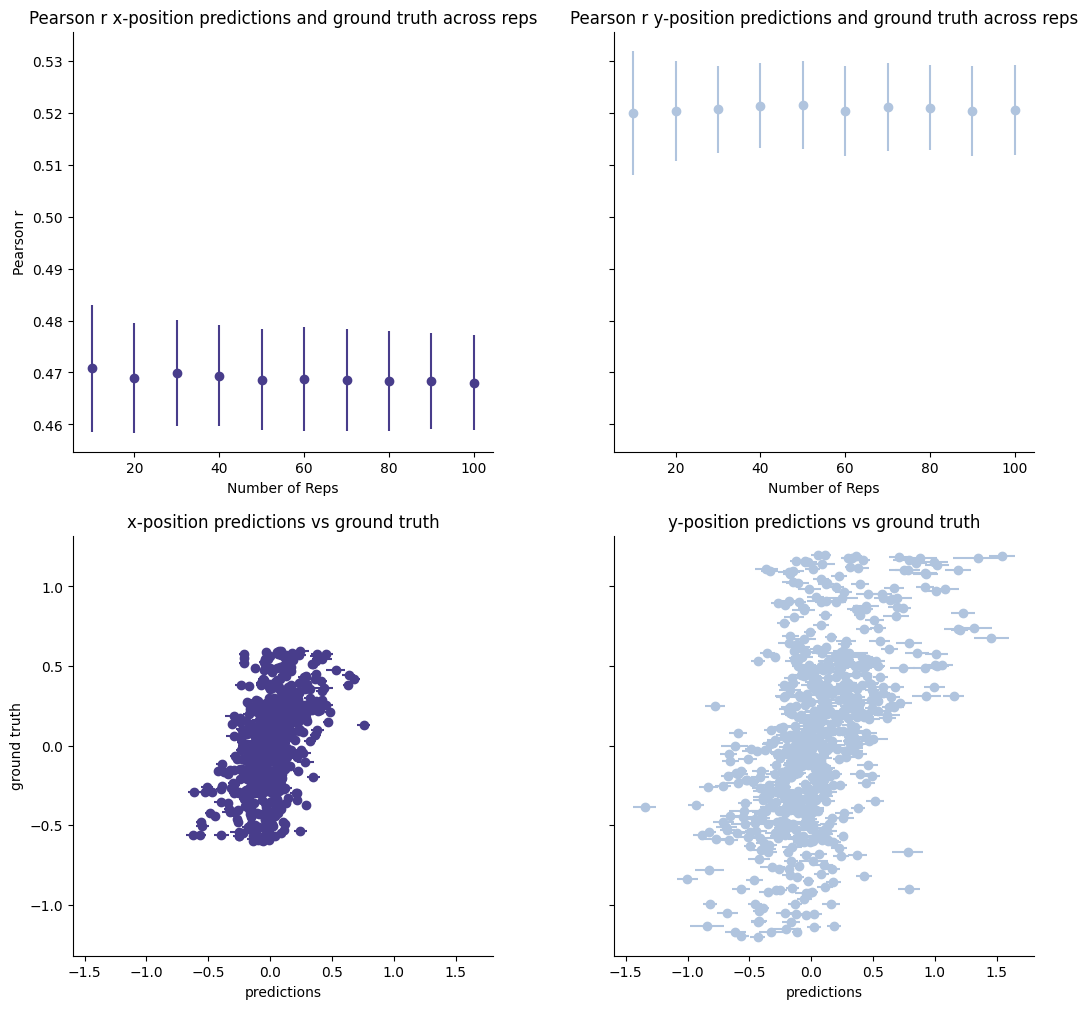

In [9]:
# simclr
simclr_bests = gt_corrs(simclr_xpreds,simclr_ypreds,xpos,ypos,100)

Final x correlation r = 0.845071086974031 +/- 0.04449887647211126
Final y correlation r = 0.8650962759728023 +/- 0.03917584650489114


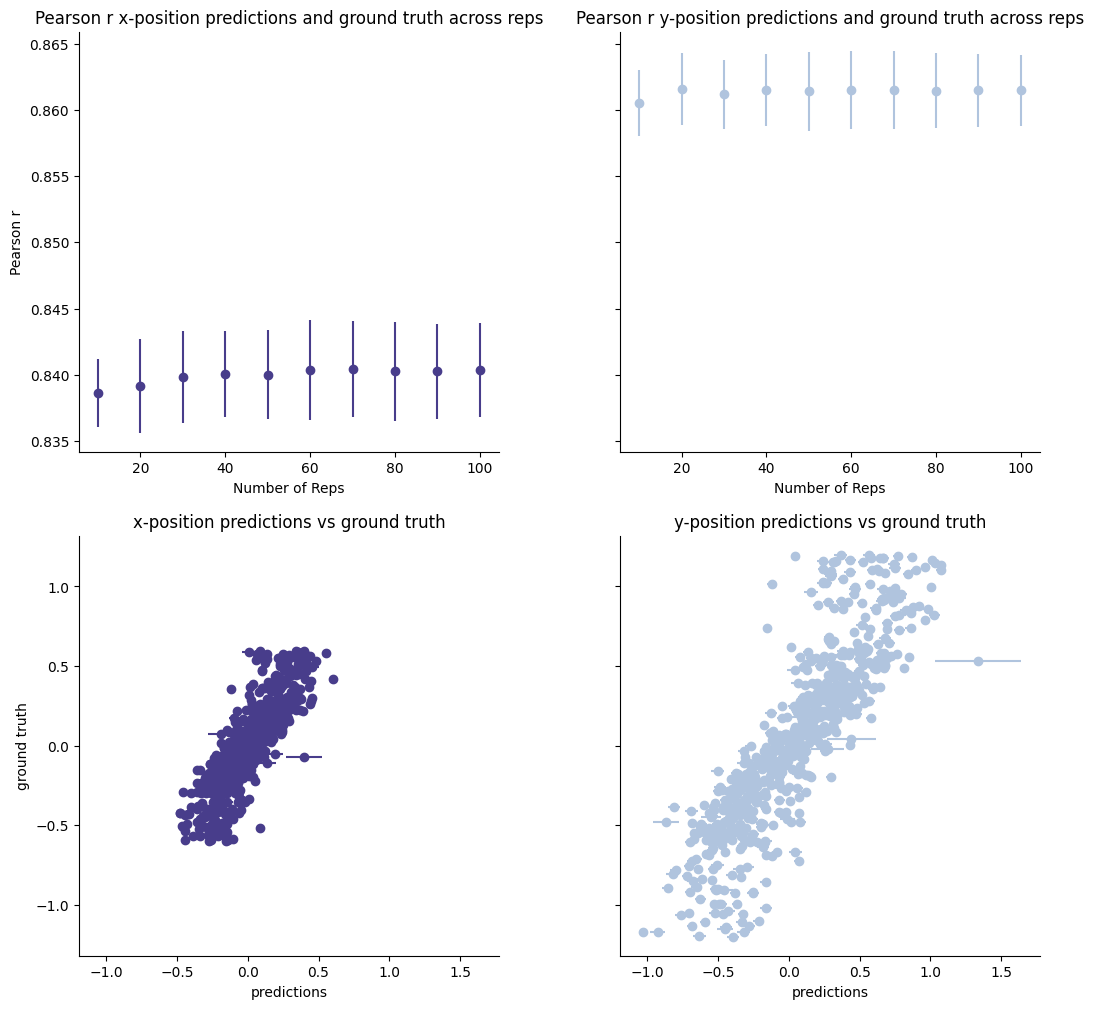

In [10]:
# resnet50 ssl
r50ssl_bests = gt_corrs(r50ssl_xpreds,r50ssl_ypreds,xpos,ypos,100)

Final x correlation r = 0.426848623139815 +/- 0.12689933954722504
Final y correlation r = 0.47951144801897994 +/- 0.11952707635346649


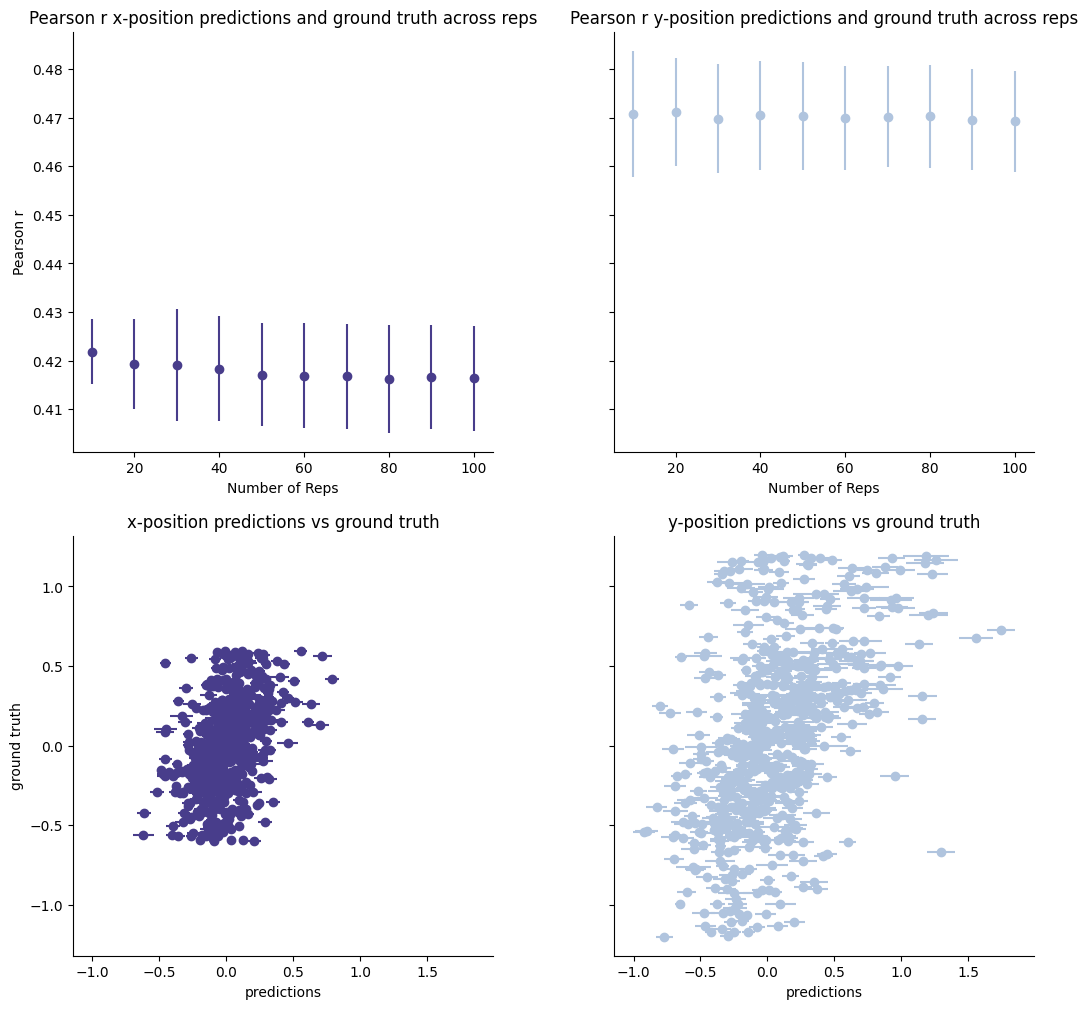

In [11]:
# resnet50 robust eps3
r50rob_bests = gt_corrs(r50rob_xpreds,r50rob_ypreds,xpos,ypos,100)

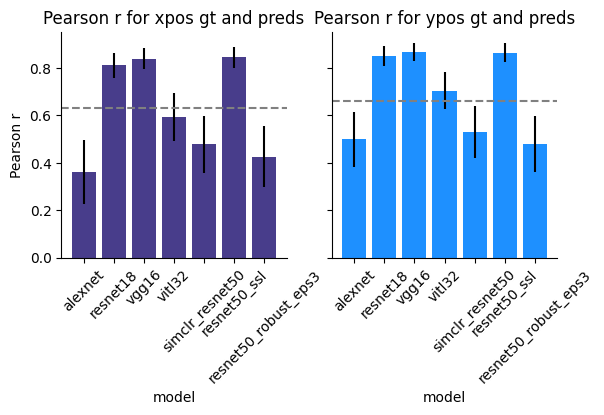

In [12]:
# bar graph of all the model correlations 
x = ['alexnet', 'resnet18', 'vgg16', 'vitl32', 'simclr_resnet50','resnet50_ssl','resnet50_robust_eps3']
y_xpos = [alexnet_bests[0],resnet_bests[0],vgg_bests[0],vit_bests[0],simclr_bests[0], r50ssl_bests[0], r50rob_bests[0]]
yerr_xpos = [alexnet_bests[1],resnet_bests[1],vgg_bests[1],vit_bests[1],simclr_bests[1], r50ssl_bests[1], r50rob_bests[1]]
y_ypos = [alexnet_bests[2],resnet_bests[2],vgg_bests[2],vit_bests[2],simclr_bests[2], r50ssl_bests[2], r50rob_bests[2]]
yerr_ypos = [alexnet_bests[3],resnet_bests[3],vgg_bests[3],vit_bests[3],simclr_bests[3], r50ssl_bests[3], r50rob_bests[3]]

fig,axs = plt.subplots(nrows=1,ncols=2,sharey=True)

axs[0].bar(x,y_xpos,yerr=yerr_xpos,color='darkslateblue', zorder=0)
axs[0].set(title='Pearson r for xpos gt and preds', xlabel='model', ylabel='Pearson r')
axs[0].axhline(y=0.63,color='grey',linestyle='--', zorder=1) # NOTE: this stat is from Hong et al., 2016
axs[1].bar(x,y_ypos,yerr=yerr_ypos,color='dodgerblue',zorder=0)
axs[1].axhline(y=0.66,color='grey',linestyle='--',zorder=1) # NOTE: this stat is from Hong et al., 2016
axs[1].set(title='Pearson r for ypos gt and preds', xlabel='model', ylabel='Pearson r')

for m in range(2):
    axs[m].spines['top'].set_visible(False)
    axs[m].spines['right'].set_visible(False)
    axs[m].tick_params(axis='x', labelrotation=45)
    x0, x1 = axs[m].get_xlim()
    y0, y1 = axs[m].get_ylim()
    axs[m].label_outer()
    axs[m].set_aspect(abs(x1 - x0) / abs(y1 - y0))

# plt.savefig('/home/eyakub/scratch/hvm640_zoo_bars.eps', format='eps', bbox_inches='tight')